Epoch [1/10], Loss: 0.4196, Accuracy: 0.8303
Epoch [2/10], Loss: 0.3156, Accuracy: 0.8783
Epoch [3/10], Loss: 0.2701, Accuracy: 0.8956
Epoch [4/10], Loss: 0.2378, Accuracy: 0.9126
Epoch [5/10], Loss: 0.1978, Accuracy: 0.9280
Epoch [6/10], Loss: 0.1616, Accuracy: 0.9431
Epoch [7/10], Loss: 0.1280, Accuracy: 0.9564
Epoch [8/10], Loss: 0.1009, Accuracy: 0.9681
Epoch [9/10], Loss: 0.0919, Accuracy: 0.9723
Epoch [10/10], Loss: 0.0693, Accuracy: 0.9802
Accuracy: 0.8859
Precision: 0.8657
Recall: 0.8442
F1 Score: 0.8549


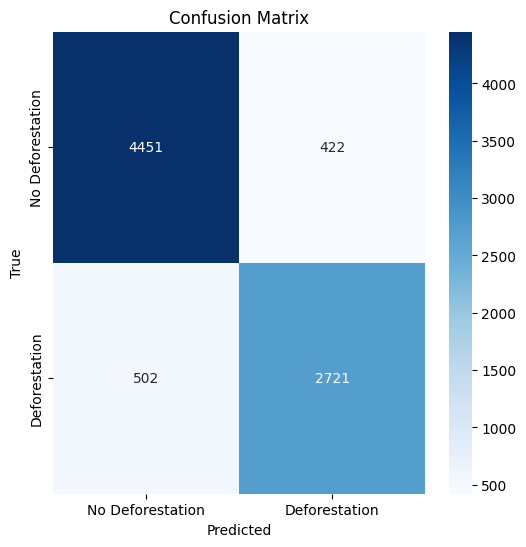

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import os
import cv2
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt
from torchvision import transforms
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns

# Load the dataset CSV file that contains the image filenames and labels
data_path = r"C:\Users\user\Desktop\Forest Monitoring\deforestaion_data\binary_class.csv"
df = pd.read_csv(data_path)

# Show the first few rows to confirm
df.head()

# Define image size and other constants
IMG_SIZE = 224
BATCH_SIZE = 32
CHANNELS = 3  # RGB images

# Custom dataset class to handle image loading and preprocessing
class DeforestationDataset(Dataset):
    def __init__(self, dataframe, image_dir, transform=None):
        self.dataframe = dataframe
        self.image_dir = image_dir
        self.transform = transform
        
    def __len__(self):
        return len(self.dataframe)
    
    def __getitem__(self, idx):
        img_name = os.path.join(self.image_dir, self.dataframe.iloc[idx, 0])  # Assuming the first column is the image filename
        image = cv2.imread(img_name)
        label = int(self.dataframe.iloc[idx, 1])  # Assuming the second column is the label
        
        # Convert image from BGR to RGB (OpenCV loads in BGR by default)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        # Resize the image
        image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
        
        if self.transform:
            image = self.transform(image)
        
        return image, label

# Define transformations for the dataset
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # Standard normalization for pre-trained models
])

# Split the dataset into training and testing sets
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

# Create training and testing datasets
train_dataset = DeforestationDataset(train_df, r"C:\Users\user\Desktop\Forest Monitoring\deforestaion_data", transform)
test_dataset = DeforestationDataset(test_df, r"C:\Users\user\Desktop\Forest Monitoring\deforestaion_data", transform)

# Create DataLoader instances for training and testing
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Define the CNN model for binary classification
class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(128 * 28 * 28, 512)
        self.fc2 = nn.Linear(512, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.pool(nn.ReLU()(self.conv1(x)))
        x = self.pool(nn.ReLU()(self.conv2(x)))
        x = self.pool(nn.ReLU()(self.conv3(x)))
        x = x.view(-1, 128 * 28 * 28)  # Flatten the output from convolutional layers
        x = nn.ReLU()(self.fc1(x))
        x = self.fc2(x)
        x = self.sigmoid(x)  # Apply sigmoid for binary classification
        return x

# Instantiate the model
model = CNNModel()

# Move the model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Define the loss function and optimizer
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training function
def train_model(model, train_loader, criterion, optimizer, epochs=20):
    model.train()
    for epoch in range(epochs):
        running_loss = 0.0
        correct = 0
        total = 0
        for inputs, labels in train_loader:
            # Move data to GPU if available
            inputs, labels = inputs.to(device), labels.to(device)

            # Zero the parameter gradients
            optimizer.zero_grad()

            # Forward pass
            outputs = model(inputs)
            loss = criterion(outputs.squeeze(), labels.float())

            # Backward pass
            loss.backward()
            optimizer.step()

            # Statistics
            running_loss += loss.item()
            predicted = (outputs > 0.5).float()  # Binary classification with threshold 0.5
            correct += (predicted.squeeze() == labels).sum().item()
            total += labels.size(0)

        epoch_loss = running_loss / len(train_loader)
        epoch_accuracy = correct / total
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss:.4f}, Accuracy: {epoch_accuracy:.4f}")

# Train the model
train_model(model, train_loader, criterion, optimizer, epochs=10)

# Modify the evaluation function to include precision, recall, F1 score, and confusion matrix
def evaluate_model(model, test_loader):
    model.eval()
    all_labels = []
    all_preds = []
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            # Move data to GPU if available
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            predicted = (outputs > 0.5).float()  # Binary classification with threshold 0.5
            
            all_labels.extend(labels.cpu().numpy())  # Move labels to CPU
            all_preds.extend(predicted.cpu().numpy())  # Move predictions to CPU
    
    # Calculate accuracy, precision, recall, and F1 score
    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds)
    recall = recall_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds)
    
    # Print metrics
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    
    # Compute confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    
    # Plot confusion matrix
    plt.figure(figsize=(6,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Deforestation', 'Deforestation'], yticklabels=['No Deforestation', 'Deforestation'])
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()

# Evaluate the model
evaluate_model(model, test_loader)

# Save the model (optional)
torch.save(model.state_dict(), "Deforestation_model.pth")
